# 🎬 IMDb Movie Review Sentiment Analysis using Classical NLP

## Project Overview

Sentiment analysis is one of the most widely used Natural Language Processing (NLP) applications. It enables machines to understand whether a piece of text expresses a positive or negative opinion.

In this project, I developed a complete end-to-end sentiment analysis pipeline using classical NLP techniques. Instead of treating the model as a black box, every preprocessing step, feature engineering decision, and model prediction is carefully analyzed and justified.

The final classifier is built using **TF-IDF** for feature extraction and **Logistic Regression** for classification, achieving approximately **90% test accuracy** on the IMDb 50K Movie Reviews dataset.

---

### Objectives

- Build a complete NLP sentiment analysis pipeline.
- Understand the purpose of every preprocessing step.
- Compare feature engineering techniques.
- Train an interpretable machine learning model.
- Explain *why* the model makes its predictions instead of reporting only accuracy.

**Import necessary libraries** (other required libraries are imported later).

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import nltk


nltk.download("omw-1.4")

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Dataset

The project uses the IMDb Movie Reviews dataset containing **50,000 labeled movie reviews**, evenly distributed between positive and negative sentiments.

The balanced nature of the dataset makes it suitable for binary sentiment classification and provides a strong benchmark for evaluating traditional NLP techniques.

**Load the dataset** using github url.

In [2]:
url = "https://raw.githubusercontent.com/ankith-b-kumar/IMBD-Movie-Reviews-Sentimental-Analysis-Classification-/main/Dataset/IMDB%20Dataset.csv"

df = pd.read_csv(url)

In [3]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df["review"][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

# Classical NLP Pipeline

Raw text often contains HTML tags, punctuation, contractions, URLs, and common words that introduce noise into machine learning models.

This section focuses on transforming raw movie reviews into clean textual features that preserve sentiment while removing unnecessary information.

Each preprocessing step is performed independently so its purpose can be clearly understood.

## Project Workflow

```
IMDb Reviews
      │
      ▼
HTML Removal
      │
      ▼
Lowercasing
      │
      ▼
Contraction Expansion
      │
      ▼
URL Removal
      │
      ▼
Punctuation Removal
      │
      ▼
Lemmatization
      │
      ▼
Stopword Removal
      │
      ▼
TF-IDF Vectorization
      │
      ▼
Train/Test Split
      │
      ▼
Logistic Regression
      │
      ▼
Evaluation
      │
      ▼
Model Interpretation
```

### HTML Parsing & Lowercasing

IMDb reviews frequently contain HTML tags such as `<br />` that are irrelevant for sentiment analysis.

These tags are removed using BeautifulSoup. Reviews are then converted to lowercase to ensure that words like **Movie**, **movie**, and **MOVIE** are treated as the same token.

In [5]:
from bs4 import BeautifulSoup

In [6]:
sample=df["review"][0]

parsed=BeautifulSoup(sample,"html.parser").get_text()

print(parsed)

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.I would say the main appeal of the show is due to the fact that it goes where other shows wou

In [7]:
df["review"] = df["review"].apply(
    lambda x: BeautifulSoup(x, "html.parser").get_text(separator=" ").lower()
)

C:\Users\HP\AppData\Local\Temp\ipykernel_7244\1751620113.py:2: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  lambda x: BeautifulSoup(x, "html.parser").get_text(separator=" ").lower()


In [8]:
print(df["review"][0])

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word. it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away. i would say the main appeal of the show is due to the fact that it goes where other shows 

### Contraction Expansion

English contractions such as **don't**, **can't**, and **I've** are expanded before punctuation removal.

For example,

don't → do not

This preserves negation words, which play an important role in sentiment analysis.

In [9]:
!pip install contractions

In [10]:
import contractions
def expand_contractions(text):
  return contractions.fix(text)

df["review_contraction"] = df["review"].apply(expand_contractions)

In [11]:
print(df["review_contraction"][0])

one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word. it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. them city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away. i would say the main appeal of the show is due to the fact that it goes where other sh

### URL Removal as they are of no use.(String starting with http, https, www.)

In [12]:
import re

#Check whether urls exists in our data

url_pattern = r"http[s]?://\S+|www\.\S+"

url_reviews = df[df["review"].str.contains(url_pattern, regex=True, na=False)]

print("Number of reviews containing URLs:", len(url_reviews))

Number of reviews containing URLs: 191


In [13]:
#Removing urls

def remove_urls(text):
    return re.sub(r"http[s]?://\S+|www\.\S+", "", text)

df["review_no_urls"] = df["review_contraction"].apply(remove_urls)
print(df["review_no_urls"][742])

url_reviews2 = df[df["review_no_urls"].str.contains(url_pattern, regex=True, na=False)]

print("Number of reviews containing URLs after removing:", len(url_reviews2))

mario lewis of the competitive enterprise institute has written a definitive 120-page point-by-point, line-by-line refutation of this mendacious film, which should be titled a convenient lie. the website address where his debunking report, which is titled "a skeptic's guide to an inconvenient truth" can be found at is : a shorter 10-page version can be found at:  once you read those demolitions, you will realize that alleged "global warming" is no more real or dangerous than the y2k scare of 1999, which gore also endorsed, as he did the pseudo-scientific film the day after tomorrow, which was based on a book written by alleged ufo abductee whitley strieber. as james "the amazing" randi does to psychics, and philip klass does to ufos, and gerald posner does to jfk conspir-idiocy theories, so does mario lewis does to al gore's movie and the whole "global warming" scam.
Number of reviews containing URLs after removing: 0


### Punctuation Removal

In [14]:
def remove_punctuation(text):
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["review_no_punctuation"] = df["review_no_urls"].apply(remove_punctuation)
print(df["review_no_punctuation"][0])

one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda them city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows would not dare forget pr

### Lemmatization.

In [15]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer=WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [16]:
def lemmatize(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word, pos="v") for word in words]
    return " ".join(lemmatized_words)

df["review_lemmatized"] = df["review_no_punctuation"].apply(lemmatize)
print(df["review_lemmatized"][0])

one of the other reviewers have mention that after watch just 1 oz episode you will be hook they be right as this be exactly what happen with me the first thing that strike me about oz be its brutality and unflinching scenes of violence which set in right from the word go trust me this be not a show for the faint hearted or timid this show pull no punch with regard to drug sex or violence its be hardcore in the classic use of the word it be call oz as that be the nickname give to the oswald maximum security state penitentary it focus mainly on emerald city an experimental section of the prison where all the cells have glass front and face inwards so privacy be not high on the agenda them city be home to many aryans muslims gangstas latinos christians italians irish and more so scuffle death star dodgy dealings and shady agreements be never far away i would say the main appeal of the show be due to the fact that it go where other show would not dare forget pretty picture paint for mains

### Stopwords Removal (Customized stopwords to preserve negation sentences).

In [17]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
negation_words = {
    "not",
    "no",
    "nor",
    "never"
}

stop_words = stop_words - negation_words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df["review_no_stopwords"] = df["review_lemmatized"].apply(remove_stopwords)
print(df["review_no_stopwords"][0])

one reviewers mention watch 1 oz episode hook right exactly happen first thing strike oz brutality unflinching scenes violence set right word go trust not show faint hearted timid show pull no punch regard drug sex violence hardcore classic use word call oz nickname give oswald maximum security state penitentary focus mainly emerald city experimental section prison cells glass front face inwards privacy not high agenda city home many aryans muslims gangstas latinos christians italians irish scuffle death star dodgy dealings shady agreements never far away would say main appeal show due fact go show would not dare forget pretty picture paint mainstream audiences forget charm forget romance oz not mess around first episode ever saw strike nasty surreal could not say ready watch develop taste oz get accustom high level graphic violence not violence injustice crook guard sell nickel inmates kill order get away well mannered middle class inmates turn prison bitch due lack street skills pris

In [19]:
df["cleaned_review"]=df["review_no_stopwords"]

# Feature Engineering

Machine learning models cannot process raw text directly.

After preprocessing, each review must be converted into numerical features.

This project uses **TF-IDF (Term Frequency–Inverse Document Frequency)** because it assigns greater importance to informative words while reducing the influence of extremely common words such as *movie*, *film*, and *character*.

Compared to Bag of Words, TF-IDF generally produces more meaningful representations for sentiment analysis.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.90,
    ngram_range=(1,2)
)

In [21]:
X = vectorizer.fit_transform(df["cleaned_review"])

In [22]:
# print(df["cleaned_review"][0])

### Encoding Labels.

In [23]:
y = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

### Train-Test-Split.

- Stratify ensures the balance between evenly divided target feature into 25,000 positive and 25,000 negative.
- 80/20 split preserves the balance.
- The training and test sets will contain equal proportions of positive and negative reviews.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Model Training

The transformed TF-IDF vectors are used to train a Logistic Regression classifier.

Logistic Regression is widely used for text classification because it is computationally efficient, performs well on sparse text features, and provides interpretable feature coefficients that help explain model predictions.

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [26]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Make Prediction.

In [27]:
y_pred = model.predict(X_test)

# Model Evaluation

The trained model is evaluated using multiple metrics rather than accuracy alone.

The following evaluation measures are used:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Together, these metrics provide a more complete understanding of the classifier's performance.

## Evaluation Beyond Accuracy

Although the model achieves approximately **89.9% accuracy**, accuracy alone does not provide a complete picture of performance.

To better evaluate the classifier, additional metrics are analyzed:

- **Precision** measures how many reviews predicted as positive (or negative) are actually correct.
- **Recall** measures how many actual positive (or negative) reviews the model successfully identifies.
- **F1-score** balances Precision and Recall, making it useful when comparing overall classification performance.
- The **Confusion Matrix** reveals the distribution of correct predictions and classification errors, helping identify false positives and false negatives.

Since the IMDb dataset is balanced, accuracy is meaningful. However, these additional metrics confirm that the classifier performs consistently across both sentiment classes rather than relying on a single evaluation measure.

### Comparison of Actual and Predicted values.

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0       0          0
1       0          0
2       1          1
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


### Accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 89.89%


### Classification report.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5000
           1       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



### Confusion Matrix.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4457  543]
 [ 468 4532]]


Text(0.5, 1.0, 'Confusion Matrix')

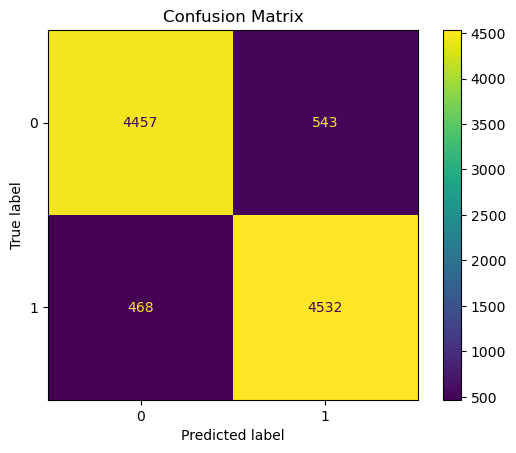

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")

# Model Performance Summary

| Metric | Value |
|---------|------:|
| Dataset | IMDb 50K Movie Reviews |
| Classification Task | Binary Sentiment Classification |
| Feature Extraction | TF-IDF |
| Machine Learning Model | Logistic Regression |
| Training Samples | 40,000 |
| Testing Samples | 10,000 |
| Test Accuracy | **89.89%** |
| Precision | **0.90** |
| Recall | **0.90** |
| F1-Score | **0.90** |

# Testing on Unseen Reviews

To evaluate how the trained classifier performs in a real-world scenario, a custom movie review that was not part of the training dataset is provided as input.

The review undergoes the same preprocessing pipeline before being transformed into TF-IDF features and classified by the trained model.

In [33]:
review = [
    "This movie was absolutely fantastic. The acting was brilliant and I loved every minute.",
    "The movie was so bad in all aspects whether it's cinematography, screenplay or vfx. Nothing worked."
]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print(prediction)

[1 0]


# Model Interpretation

One of the advantages of Logistic Regression is its interpretability.

Each feature receives a learned coefficient during training.

- Positive coefficients push predictions toward the Positive class.
- Negative coefficients push predictions toward the Negative class.
- Larger absolute values indicate stronger influence.

By examining these coefficients, we can understand what linguistic patterns the classifier has learned instead of treating it as a black box.

### Understanding What the Model Learned

Logistic Regression assigns a coefficient to every TF-IDF feature.

Words with positive coefficients increase the probability of a Positive prediction, while words with negative coefficients increase the probability of a Negative prediction.

Examining these coefficients helps interpret the model instead of treating it as a black box.

In [34]:
weights = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Coefficient": model.coef_[0]
})

print("Top 20 Positive Words")
print(weights.sort_values("Coefficient", ascending=False).head(20))

print("\nTop 20 Negative Words")
print(weights.sort_values("Coefficient").head(20))

Top 20 Positive Words
                Word  Coefficient
1422       excellent     6.870797
1936           great     6.492787
3343         perfect     5.475106
4901       wonderful     4.817293
215            amaze     4.665017
2057       hilarious     4.559352
554        brilliant     4.331906
2550            love     4.179175
1331           enjoy     4.123676
3190        one best     4.083878
1521        favorite     3.992256
436             best     3.991220
4323          superb     3.985578
1335       enjoyable     3.984988
1084      definitely     3.902293
4531           today     3.868763
1766             fun     3.729428
3047  not disappoint     3.653848
1343       entertain     3.559249
1501       fantastic     3.537431

Top 20 Negative Words
                Word  Coefficient
4921           worst    -9.310444
350            awful    -7.952972
4798           waste    -7.849855
359              bad    -7.139395
518             bore    -6.646454
3440            poor    -5.722228
442

In [35]:
review_vector = X[0].toarray()[0]

feature_names = vectorizer.get_feature_names_out()

review_df = pd.DataFrame({
    "Word": feature_names,
    "TF-IDF": review_vector,
    "Coefficient": model.coef_[0]
})

review_df = review_df[review_df["TF-IDF"] > 0]

review_df["Contribution"] = (
    review_df["TF-IDF"] * review_df["Coefficient"]
)

review_df.sort_values("Contribution", ascending=False)

,Word,TF-IDF,Coefficient,Contribution
3274,oz,0.566119,0.397212,0.224869
4551,touch,0.058301,3.262791,0.190224
776,classic,0.053739,2.917673,0.156792
4025,show,0.138151,1.111426,0.153545
1353,episode,0.121471,1.065886,0.129474
...,...,...,...,...
3514,prison,0.228766,-0.620672,-0.141988
4933,would,0.055675,-3.132653,-0.174410
2719,mess,0.064831,-3.411327,-0.221160
2384,lack,0.053367,-4.303051,-0.229639


# Key Learnings

Through this project I learned:

- Why preprocessing order matters in NLP.
- Why negation words should be preserved.
- Difference between TF-IDF values and Logistic Regression coefficients.
- Importance of model interpretability.
- Trade-offs between computational efficiency and linguistic preprocessing.

# Conclusion

This project demonstrates a complete classical NLP workflow for binary sentiment classification.

Beyond achieving strong predictive performance, the project emphasizes understanding the reasoning behind every preprocessing decision, feature engineering technique, and model prediction.

The interpretability of Logistic Regression provides valuable insights into the words and phrases that influence sentiment classification, making the project both technically effective and easy to explain during interviews.